In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import ast

In [2]:
# Read in data, here survival data from TCGA and KRAS mutation annotations for TCGA tumors
KRAS_mut_status = pd.read_csv('data/KRAS_mut_status_tumors.csv')
surv = pd.read_csv('data/survival_data.csv')

In [3]:
# Create a dictionary mapping mutation category -> tumor list (as strings)
dict_tumors = dict(zip(KRAS_mut_status['mut'], KRAS_mut_status['tumor']))
# Convert tumor lists from strings into actual Python lists
dict_tumors = {
    group: ast.literal_eval(patients)
    for group, patients in dict_tumors.items()
}

In [4]:
# build patient -> group mapping from your dict
patient_to_group = {}

for group, patients in dict_tumors.items():
    for pid in patients:
        patient_to_group[str(pid)[:12]] = group

# assign group labels
surv['group'] = surv['_PATIENT'].map(patient_to_group)

# keep only patients that appear in your dict
surv = surv.dropna().copy()

# if the same patient appears more than once, keep one row
surv = surv.drop_duplicates(subset=['_PATIENT'])

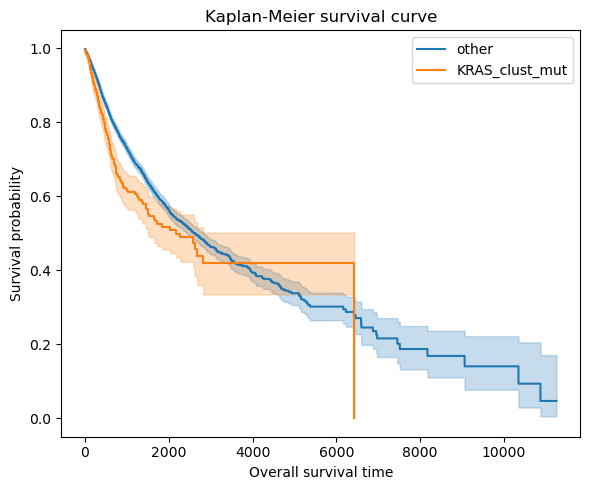

In [5]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for group in surv['group'].unique():
    sub = surv[surv['group'] == group]
    kmf.fit(
        durations=sub['OS.time'],
        event_observed=sub['OS'],
        label=group
    )
    kmf.plot_survival_function()

plt.xlabel("Overall survival time")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival curve")
plt.tight_layout()
plt.show()

In [6]:
g1 = surv[surv['group'] == 'KRAS_clust_mut']
g2 = surv[surv['group'] == 'other']

result = logrank_test(
    g1['OS.time'],
    g2['OS.time'],
    event_observed_A=g1['OS'],
    event_observed_B=g2['OS']
)

print("log-rank p-value:", result.p_value)

log-rank p-value: 2.5048577065932648e-05
